## Supplementary analysis for the test 3 Theory Generation

### Imports

In [1]:
# Standalone bootstrap for this notebook.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore", category=FutureWarning)

2026-04-08 10:51:41.599906: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-08 10:51:47.432949: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
# --- paths ---
project_dir = Path.cwd()
output_dir = project_dir / "results" / "test3_theory_generation_alternative"
output_dir.mkdir(parents=True, exist_ok=True)

# --- project-wide style and palettes ---
from setups.viz_styles import (
    apply_project_style,
    WHITE_SKY_CMAP, SKY_WHITE_GRAY_CMAP,
    BLUE_GRAY_RAMP, MODEL_VISIBLE_COLORS, THRESHOLD_COLOR, TEXT_COLOR,
)
apply_project_style()

# --- shared analysis thresholds ---
from setups.thresholds import (
    T3_DERIVATIVE_SIMILARITY_THRESHOLD as DERIVATIVE_SIMILARITY_THRESHOLD,
    T3_SEMANTIC_DISTANCE_THRESHOLD     as SEMANTIC_DISTANCE_THRESHOLD,
)


### Load Shared Combined-Space Artifacts

In [3]:
# Paths to the exact combined-space artifacts produced by 4-test3-theory-generation.ipynb.
source_output_dir = Path('results/test3_theory_generation')
source_combination_dir = source_output_dir / 'theory_combination'
embedding_bundle_file = source_output_dir / 'test3_combined_embedding_bundle.npz'
ai_semantic_csv = source_combination_dir / 'ai_theories_02_after_semantic.csv'
known_semantic_csv = source_combination_dir / 'known_theories_02_after_semantic.csv'

missing_artifacts = [
    str(p) for p in [embedding_bundle_file, ai_semantic_csv, known_semantic_csv]
    if not p.exists()
]
if missing_artifacts:
    raise FileNotFoundError(
        'Missing shared artifacts from 4-test3-theory-generation.ipynb:\n'
        + '\n'.join(missing_artifacts)
        + '\n\nRun the combination/embedding cells in 4-test3 first.'
    )

print('Shared artifact files found.')
print(f'  Bundle: {embedding_bundle_file}')
print(f'  AI semantic table: {ai_semantic_csv}')
print(f'  Known semantic table: {known_semantic_csv}')

Shared artifact files found.
  Bundle: results/test3_theory_generation/test3_combined_embedding_bundle.npz
  AI semantic table: results/test3_theory_generation/theory_combination/ai_theories_02_after_semantic.csv
  Known semantic table: results/test3_theory_generation/theory_combination/known_theories_02_after_semantic.csv


### Embeddings

In [4]:
# --- embeddings ---
# Load the exact semantic-unique tables and embedding bundle from 4-test3.
ai_unique_df = pd.read_csv(ai_semantic_csv)
known_unique_df = pd.read_csv(known_semantic_csv)

with np.load(embedding_bundle_file) as z:
    ai_unique_emb = z['ai_unique_emb']
    known_unique_emb = z['known_unique_emb']
    similarity_matrix_combined = z['similarity_matrix_combined']

# Ensure compatibility with diagnostics expecting a single model column.
if 'model' not in ai_unique_df.columns:
    if 'models' in ai_unique_df.columns:
        ai_unique_df['model'] = (
            ai_unique_df['models']
            .astype(str)
            .str.split(r'\s*\|\|\s*', regex=True)
            .str[0]
            .fillna('unknown')
        )
    else:
        ai_unique_df['model'] = 'unknown'

# Compatibility aliases used by some plotting/diagnostic cells.
ai_theories = ai_unique_df[['canonical_name', 'representative_text', 'model']].rename(
    columns={'canonical_name': 'theory_name', 'representative_text': 'full_text'}
).to_dict(orient='records')
known_theories = dict(
    zip(
        known_unique_df['canonical_name'].astype(str),
        known_unique_df['representative_text'].astype(str),
    )
)

# Sanity checks for exact alignment.
if ai_unique_emb.shape[0] != len(ai_unique_df):
    raise ValueError(
        f'AI embedding rows ({ai_unique_emb.shape[0]}) != AI semantic rows ({len(ai_unique_df)}).'
    )
if known_unique_emb.shape[0] != len(known_unique_df):
    raise ValueError(
        f'Known embedding rows ({known_unique_emb.shape[0]}) != known semantic rows ({len(known_unique_df)}).'
    )

print('Loaded exact combined-space artifacts from 4-test3-theory-generation.ipynb')
print(f'  AI semantic rows: {len(ai_unique_df)}')
print(f'  Known semantic rows: {len(known_unique_df)}')
print(f'  Bundle: {embedding_bundle_file}')

Loaded exact combined-space artifacts from 4-test3-theory-generation.ipynb
  AI semantic rows: 67
  Known semantic rows: 39
  Bundle: results/test3_theory_generation/test3_combined_embedding_bundle.npz


In [5]:
print("Setup complete")
print(f"AI theories: {len(ai_unique_df)}")
print(f"Known theories: {len(known_unique_df)}")
print(f"AI embedding shape: {ai_unique_emb.shape}")
print(f"Known embedding shape: {known_unique_emb.shape}")
print(f"Output dir: {output_dir}")

Setup complete
AI theories: 67
Known theories: 39
AI embedding shape: (67, 384)
Known embedding shape: (39, 384)
Output dir: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative


## 5.1 Joint 2D Cluster Map (AI + Known)

Project both AI and known theories into a shared 2D space and detect clusters with a density-first method.

- Preferred clustering: `HDBSCAN` (if available)
- Fallback clustering: agglomerative cosine clustering
- Preferred projection: `UMAP` (if available)
- Fallback projection: `PCA + t-SNE`

In [6]:
# Build a joint dataset (AI + known) for shared clustering and 2D projection.
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

/home/jarnoma/anaconda3/envs/aitrust/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


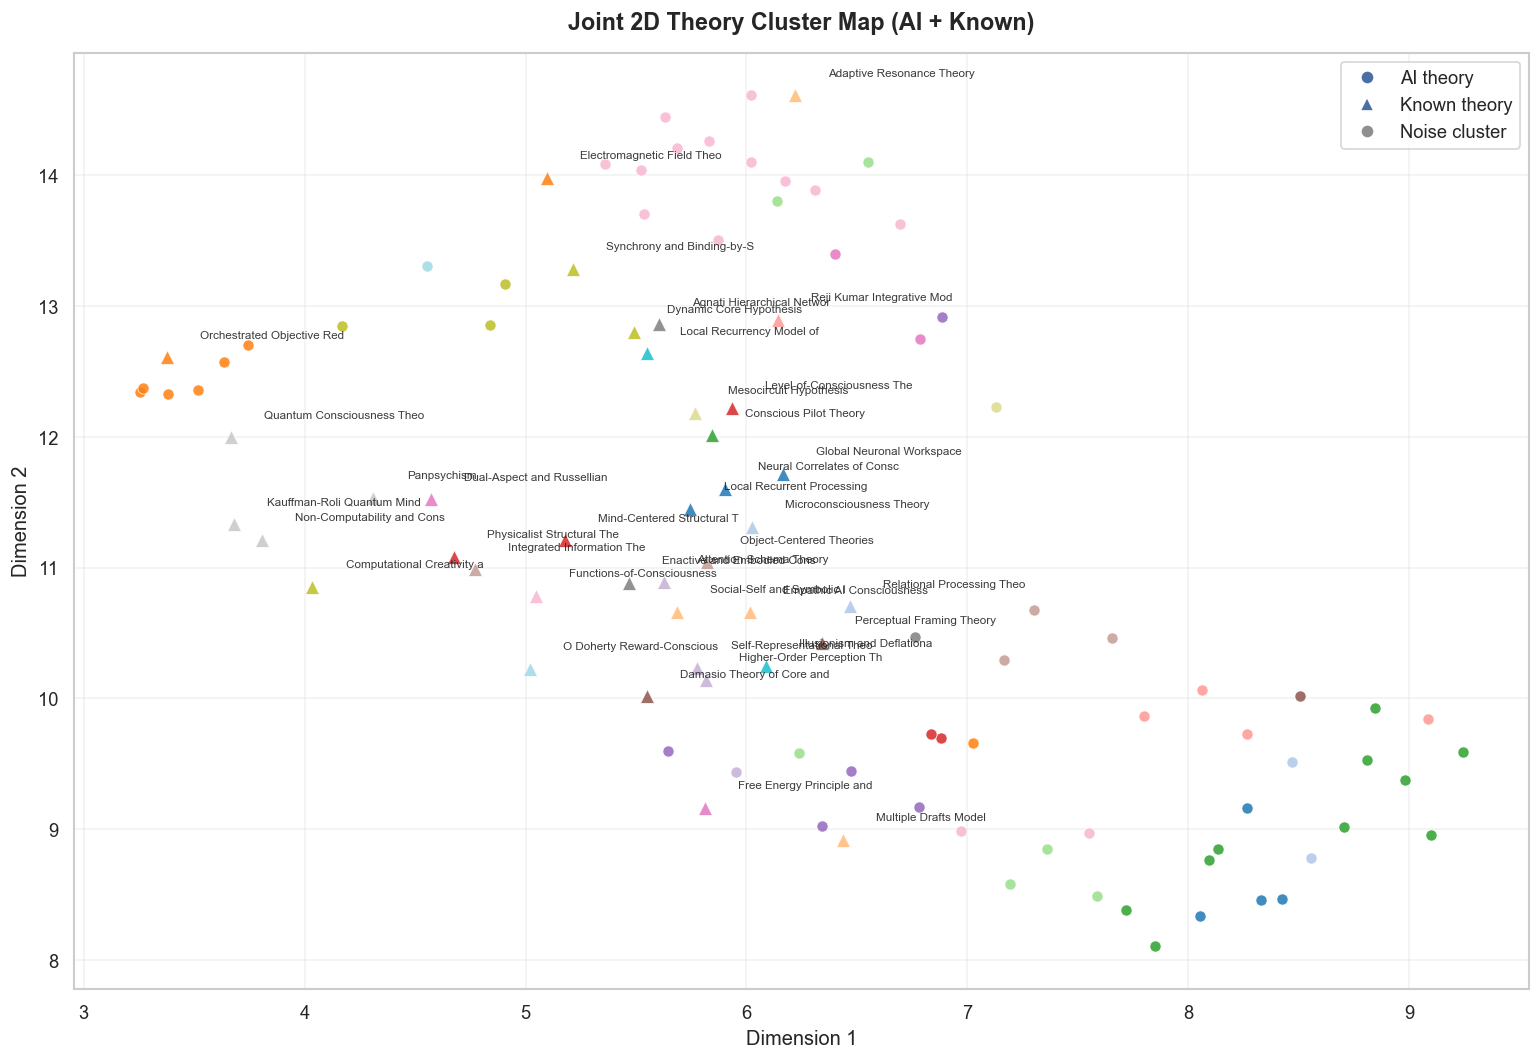

2D cluster map complete
Clustering method: Agglomerative(cosine, threshold=0.3)
Projection method: UMAP(metric=cosine)
Total points: 106
Non-noise clusters: 57
Noise points: 0
Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_cluster_map_2d.png
Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_cluster_map_2d_points.csv
Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_cluster_map_2d_cluster_summary.csv


group,cluster_id,n_ai,n_known,n_total
0,13,12,0,12
1,4,7,0,7
2,2,6,1,7
3,16,3,1,4
4,0,4,0,4
5,7,3,0,3
6,8,3,0,3
7,25,3,0,3
8,24,3,0,3
9,11,3,0,3


In [7]:
if 'ai_unique_emb' in globals() and 'known_unique_emb' in globals():
    ai_names_joint = ai_unique_df['canonical_name'].astype(str).tolist()
    known_names_joint = known_unique_df['canonical_name'].astype(str).tolist()
    ai_emb_joint = np.asarray(ai_unique_emb)
    known_emb_joint = np.asarray(known_unique_emb)
else:
    if 'embedder' not in globals() or embedder is None:
        embedder = SentenceTransformer('all-MiniLM-L6-v2')

    ai_names_joint = [str(t.get('theory_name', '')) for t in ai_theories]
    ai_text_joint = [str(t.get('full_text', '')) for t in ai_theories]
    known_names_joint = list(known_theories.keys())
    known_text_joint = [str(known_theories[k]) for k in known_names_joint]

    ai_emb_joint = np.asarray(embedder.encode(ai_text_joint, show_progress_bar=True))
    known_emb_joint = np.asarray(embedder.encode(known_text_joint, show_progress_bar=True))

all_names = ai_names_joint + known_names_joint
all_group = (['AI'] * len(ai_names_joint)) + (['Known'] * len(known_names_joint))
all_embeddings = np.vstack([ai_emb_joint, known_emb_joint]).astype(float)

n_points = all_embeddings.shape[0]
if n_points < 3:
    raise ValueError('Need at least 3 points to compute a meaningful 2D cluster map.')

# --- Preferred clustering: HDBSCAN on embedding space; fallback: agglomerative cosine ---
cluster_method = ''
use_hdbscan = False
try:
    import hdbscan
    min_cluster_size = max(3, int(np.sqrt(n_points)))
    min_samples = max(2, min_cluster_size // 2)
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean',
        cluster_selection_method='eom'
    )
    hdb_labels = clusterer.fit_predict(all_embeddings)  # -1 means noise
    non_noise_clusters = sorted(set(hdb_labels[hdb_labels >= 0].tolist()))

    # If HDBSCAN finds no meaningful structure, fallback to deterministic agglomerative clusters.
    if len(non_noise_clusters) >= 2:
        cluster_labels = hdb_labels
        cluster_method = f'HDBSCAN(min_cluster_size={min_cluster_size}, min_samples={min_samples})'
        use_hdbscan = True
    else:
        raise RuntimeError('HDBSCAN produced only noise or a single cluster; switching to agglomerative.')
except Exception:
    # Fallback keeps consistency with cosine-based semantic grouping used earlier in the notebook.
    try:
        agg = AgglomerativeClustering(
            n_clusters=None,
            metric='cosine',
            linkage='average',
            distance_threshold=SEMANTIC_DISTANCE_THRESHOLD
        )
    except TypeError:
        agg = AgglomerativeClustering(
            n_clusters=None,
            affinity='cosine',
            linkage='average',
            distance_threshold=SEMANTIC_DISTANCE_THRESHOLD
        )
    cluster_labels = agg.fit_predict(all_embeddings)
    cluster_method = f'Agglomerative(cosine, threshold={SEMANTIC_DISTANCE_THRESHOLD})'

# --- Preferred projection: UMAP; fallback: PCA + t-SNE ---
projection_method = ''
try:
    import umap
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(15, n_points - 1),
        min_dist=0.15,
        metric='cosine',
        random_state=42
    )
    points_2d = reducer.fit_transform(all_embeddings)
    projection_method = 'UMAP(metric=cosine)'
except Exception:
    pca_dims = max(2, min(50, all_embeddings.shape[1], n_points - 1))
    pca = PCA(n_components=pca_dims, random_state=42)
    reduced = pca.fit_transform(all_embeddings)

    if n_points <= 5:
        points_2d = reduced[:, :2]
        projection_method = f'PCA({pca_dims}) -> first 2 PCs (small-sample fallback)'
    else:
        perplexity = min(30, max(5, (n_points - 1) // 3))
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            init='pca',
            learning_rate='auto',
            random_state=42
        )
        points_2d = tsne.fit_transform(reduced)
        projection_method = f'PCA({pca_dims}) + t-SNE(perplexity={perplexity})'

cluster_map_df = pd.DataFrame({
    'theory_name': all_names,
    'group': all_group,
    'cluster_id': cluster_labels.astype(int),
    'x': points_2d[:, 0],
    'y': points_2d[:, 1],
})
cluster_map_df['cluster_label'] = cluster_map_df['cluster_id'].map(lambda c: f'Noise ({c})' if c < 0 else f'Cluster {c}')

# Save points for reproducibility.
cluster_map_df.to_csv(output_dir / 'theory_cluster_map_2d_points.csv', index=False)

# Plot: color by cluster, marker by source group.
fig, ax = plt.subplots(figsize=(13, 9))
unique_clusters = sorted(cluster_map_df['cluster_id'].unique().tolist())
palette = sns.color_palette('tab20', n_colors=max(1, len([c for c in unique_clusters if c >= 0])))
cluster_to_color = {}
pal_idx = 0
for c in unique_clusters:
    if c < 0:
        cluster_to_color[c] = '#8f8f8f'
    else:
        cluster_to_color[c] = palette[pal_idx % len(palette)]
        pal_idx += 1

marker_map = {'AI': 'o', 'Known': '^'}
for grp in ['AI', 'Known']:
    grp_df = cluster_map_df[cluster_map_df['group'] == grp]
    for c in unique_clusters:
        sub = grp_df[grp_df['cluster_id'] == c]
        if sub.empty:
            continue
        ax.scatter(
            sub['x'],
            sub['y'],
            s=70 if grp == 'Known' else 45,
            marker=marker_map[grp],
            c=[cluster_to_color[c]],
            alpha=0.85,
            edgecolors='white',
            linewidths=0.5,
        )

# Label only known-theory points for interpretability.
known_points = cluster_map_df[cluster_map_df['group'] == 'Known'].copy()
for _, row in known_points.iterrows():
    short_name = str(row['theory_name'])[:26]
    ax.text(row['x'] + 0.15, row['y'] + 0.15, short_name, fontsize=7, alpha=0.9)

# Build compact legend for source markers.
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker='o', color='w', label='AI theory', markerfacecolor='#4a6fa5', markersize=8),
    Line2D([0], [0], marker='^', color='w', label='Known theory', markerfacecolor='#4a6fa5', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Noise cluster', markerfacecolor='#8f8f8f', markersize=8),
]
ax.legend(handles=legend_items, loc='upper right', frameon=True)

ax.set_title(
    'Joint 2D Theory Cluster Map (AI + Known)',
    fontsize=14,
    fontweight='bold',
    pad=14
    )
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(output_dir / 'theory_cluster_map_2d.png', dpi=300, bbox_inches='tight')
plt.show()

cluster_summary = (
    cluster_map_df.groupby(['cluster_id', 'group']).size()
    .unstack(fill_value=0)
    .reset_index()
    .sort_values(['cluster_id'])
    .rename(columns={'AI': 'n_ai', 'Known': 'n_known'})
)
cluster_summary['n_total'] = cluster_summary['n_ai'] + cluster_summary['n_known']
cluster_summary = cluster_summary.sort_values('n_total', ascending=False).reset_index(drop=True)
cluster_summary.to_csv(output_dir / 'theory_cluster_map_2d_cluster_summary.csv', index=False)

n_noise = int((cluster_map_df['cluster_id'] < 0).sum())
n_clusters_non_noise = int(cluster_map_df.loc[cluster_map_df['cluster_id'] >= 0, 'cluster_id'].nunique())

print('2D cluster map complete')
print(f'Clustering method: {cluster_method}')
print(f'Projection method: {projection_method}')
print(f'Total points: {len(cluster_map_df)}')
print(f'Non-noise clusters: {n_clusters_non_noise}')
print(f'Noise points: {n_noise}')
print(f"Saved: {output_dir / 'theory_cluster_map_2d.png'}")
print(f"Saved: {output_dir / 'theory_cluster_map_2d_points.csv'}")
print(f"Saved: {output_dir / 'theory_cluster_map_2d_cluster_summary.csv'}")

cluster_summary.head(20)

### 5.1.1 Setup A: Cluster Centroids + Convex Hulls

Cleaner cluster geometry view: draw AI points lightly, known points prominently, centroid labels, and optional convex hull boundaries for clusters with >=3 points.

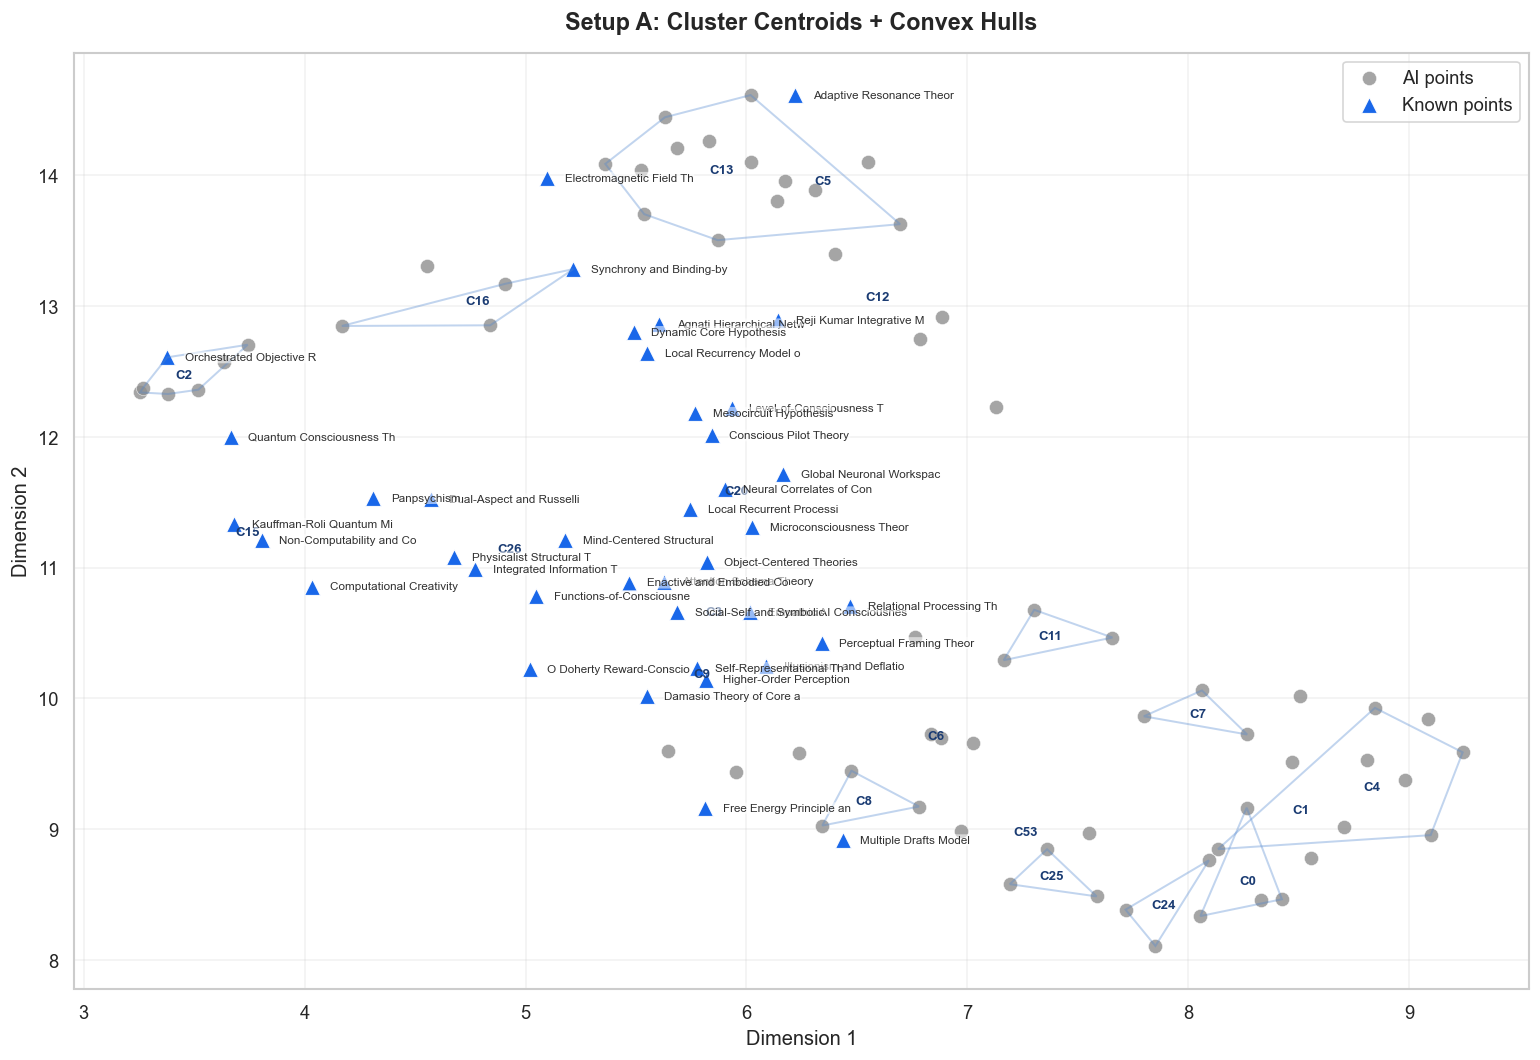

Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_cluster_map_setupA_centroids_hulls.png
Convex hull support: enabled


In [8]:
# Setup A: centroid/hull view for cleaner cluster geometry.
from matplotlib.patches import Polygon

setup_a_df = cluster_map_df.copy()
fig, ax = plt.subplots(figsize=(13, 9))

# Try convex hulls when scipy is available.
has_hull = True
try:
    from scipy.spatial import ConvexHull
except Exception:
    has_hull = False

# Background AI points: high contrast, 3x size, alpha=0.8.
ai_pts = setup_a_df[setup_a_df['group'] == 'AI']
ai_point_color = (
    mpl.colors.to_hex(SKY_WHITE_GRAY_CMAP(1.00))
    if 'SKY_WHITE_GRAY_CMAP' in globals()
    else (BLUE_GRAY_RAMP[3] if 'BLUE_GRAY_RAMP' in globals() and len(BLUE_GRAY_RAMP) > 3 else '#7f7f7f')
)
ax.scatter(
    ai_pts['x'],
    ai_pts['y'],
    s=72,
    c=ai_point_color,
    alpha=0.8,
    marker='o',
    edgecolors='white',
    linewidths=0.35,
    label='AI points'
)

# Known points foreground: distinct color sampled from predefined colormap.
known_pts = setup_a_df[setup_a_df['group'] == 'Known']
known_point_color = (
    mpl.colors.to_hex(WHITE_SKY_CMAP(0.95))
    if 'WHITE_SKY_CMAP' in globals()
    else (MODEL_VISIBLE_COLORS[0] if 'MODEL_VISIBLE_COLORS' in globals() and len(MODEL_VISIBLE_COLORS) else '#0b3c8c')
)
ax.scatter(
    known_pts['x'],
    known_pts['y'],
    s=90,
    c=known_point_color,
    alpha=0.95,
    marker='^',
    edgecolors='white',
    linewidths=0.6,
    label='Known points'
)

# Draw hull and centroid per cluster.
for cid in sorted(setup_a_df['cluster_id'].unique().tolist()):
    cdf = setup_a_df[setup_a_df['cluster_id'] == cid]
    pts = cdf[['x', 'y']].to_numpy()
    color = '#b0b0b0' if cid < 0 else '#4f86cf'

    if has_hull and cid >= 0 and len(pts) >= 3:
        try:
            hull = ConvexHull(pts)
            poly = Polygon(pts[hull.vertices], closed=True, fill=False, edgecolor=color, linewidth=1.2, alpha=0.35)
            ax.add_patch(poly)
        except Exception:
            pass

    cx, cy = float(np.mean(pts[:, 0])), float(np.mean(pts[:, 1]))
    # Show centroid labels only for non-singleton clusters.
    if cid >= 0 and len(cdf) > 1:
        ax.text(cx, cy, f'C{cid}', fontsize=8, fontweight='bold', color='#1b3c73', ha='center', va='center')

# Label known theories directly next to their points on the right.
x_span = float(setup_a_df['x'].max() - setup_a_df['x'].min()) if len(setup_a_df) else 1.0
label_dx = max(0.010 * x_span, 0.08)

for _, row in known_pts.iterrows():
    x0 = float(row['x'])
    y0 = float(row['y'])
    label_text = str(row['theory_name'])[:24]
    ax.text(
        x0 + label_dx,
        y0,
        label_text,
        fontsize=7,
        alpha=0.95,
        ha='left',
        va='center',
        bbox=dict(boxstyle='round,pad=0.08', facecolor='white', edgecolor='none', alpha=0.55),
    )

ax.set_title('Setup A: Cluster Centroids + Convex Hulls', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, alpha=0.25)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig(output_dir / 'theory_cluster_map_setupA_centroids_hulls.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {output_dir / 'theory_cluster_map_setupA_centroids_hulls.png'}")
print(f"Convex hull support: {'enabled' if has_hull else 'not available'}")

### 5.1.2 Setup B: Color By Novelty Status

Color AI points by novelty rule (`similarity_to_known <= 0.30` is novel candidate, otherwise derivative), keep known theories as reference anchors.

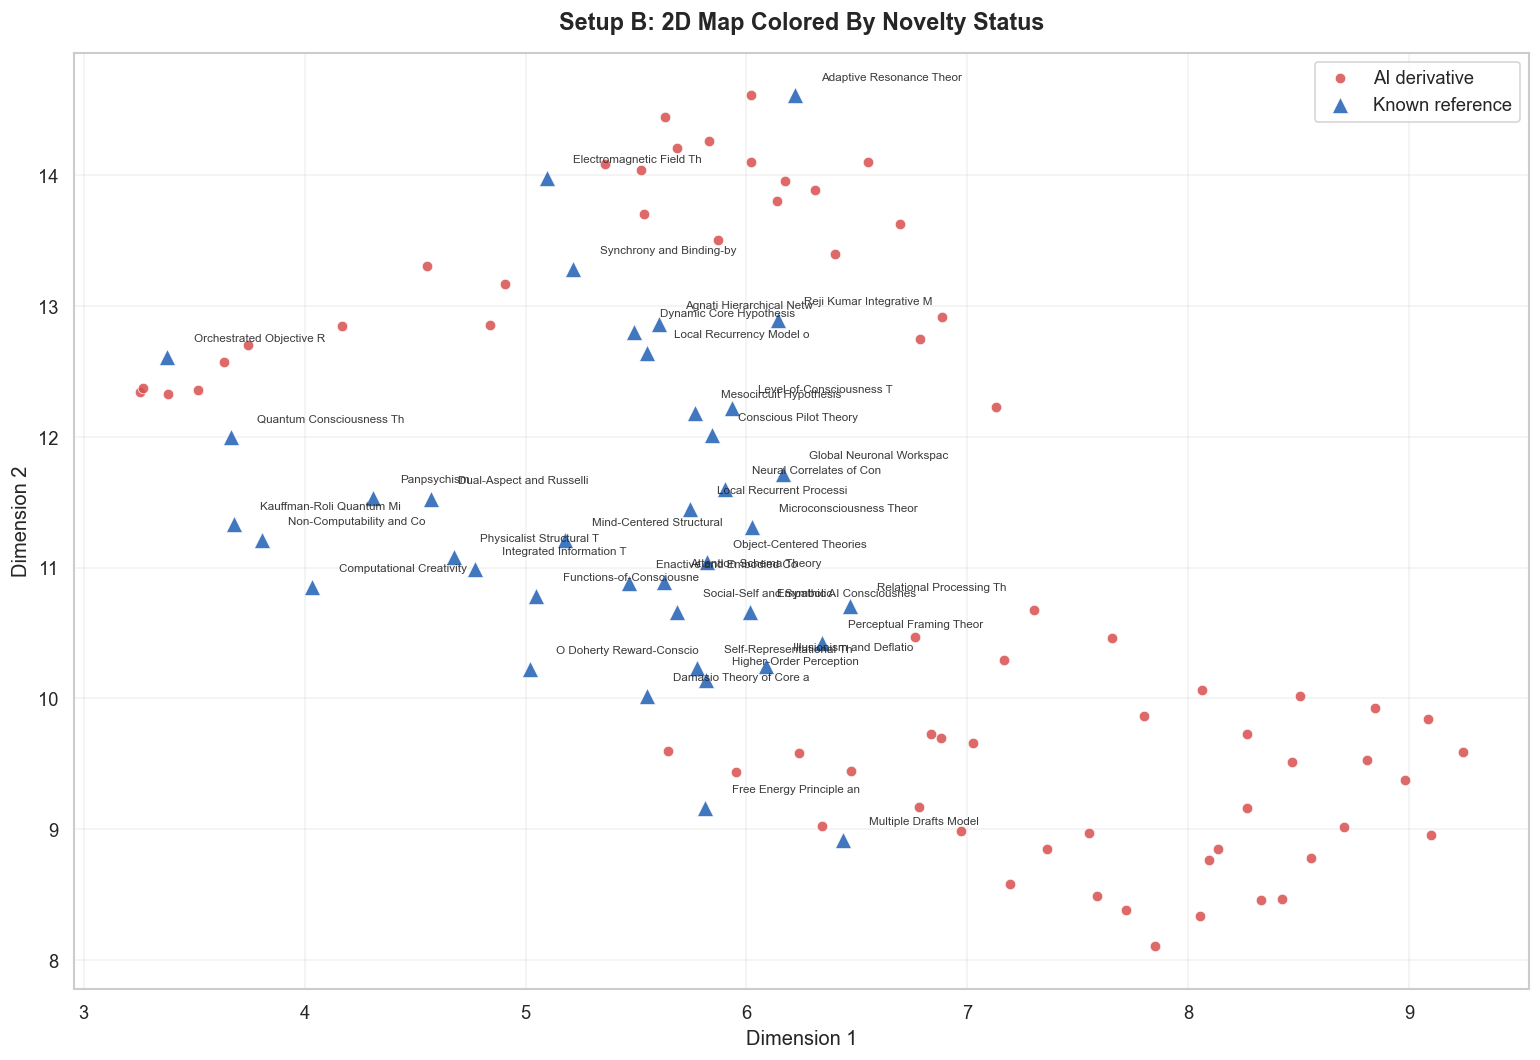

Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_cluster_map_setupB_novelty_colors.png
Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_cluster_map_setupB_novelty_counts.csv


,status,count
0,AI derivative,67
1,Known reference,39


In [9]:
# Setup B: color by novelty status using threshold rule.
setup_b_df = cluster_map_df.copy()

# Build AI max-similarity lookup aligned with current semantic-unique AI space when available.
if 'similarity_matrix_combined' in globals() and 'ai_unique_df' in globals():
    ai_max_sim = similarity_matrix_combined.max(axis=1)
    ai_name_to_sim = {
        str(name): float(sim)
        for name, sim in zip(ai_unique_df['canonical_name'].astype(str).tolist(), ai_max_sim)
    }
else:
    ai_name_to_sim = {
        str(t.get('theory_name', '')): float(t.get('similarity_to_known', np.nan))
        for t in ai_theories
    }

def _novelty_status(row):
    if row['group'] == 'Known':
        return 'Known reference'
    sim_val = ai_name_to_sim.get(str(row['theory_name']), np.nan)
    if np.isnan(sim_val):
        return 'AI unknown-sim'
    return 'AI novel candidate' if sim_val <= DERIVATIVE_SIMILARITY_THRESHOLD else 'AI derivative'

setup_b_df['novelty_status'] = setup_b_df.apply(_novelty_status, axis=1)

status_colors = {
    'AI novel candidate': '#2e8b57',
    'AI derivative': '#d94f4f',
    'AI unknown-sim': '#9a9a9a',
    'Known reference': '#1f5fb3',
}
status_markers = {
    'AI novel candidate': 'o',
    'AI derivative': 'o',
    'AI unknown-sim': 'o',
    'Known reference': '^',
}
status_sizes = {
    'AI novel candidate': 48,
    'AI derivative': 40,
    'AI unknown-sim': 40,
    'Known reference': 95,
}

fig, ax = plt.subplots(figsize=(13, 9))
for status in ['AI novel candidate', 'AI derivative', 'AI unknown-sim', 'Known reference']:
    sdf = setup_b_df[setup_b_df['novelty_status'] == status]
    if sdf.empty:
        continue
    ax.scatter(
        sdf['x'], sdf['y'],
        c=status_colors[status],
        marker=status_markers[status],
        s=status_sizes[status],
        alpha=0.85,
        edgecolors='white',
        linewidths=0.5,
        label=status
    )

known_pts = setup_b_df[setup_b_df['group'] == 'Known']
for _, row in known_pts.iterrows():
    ax.text(row['x'] + 0.12, row['y'] + 0.12, str(row['theory_name'])[:24], fontsize=7, alpha=0.9)

ax.set_title('Setup B: 2D Map Colored By Novelty Status', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, alpha=0.25)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig(output_dir / 'theory_cluster_map_setupB_novelty_colors.png', dpi=300, bbox_inches='tight')
plt.show()

status_counts = setup_b_df['novelty_status'].value_counts(dropna=False).rename_axis('status').reset_index(name='count')
status_counts.to_csv(output_dir / 'theory_cluster_map_setupB_novelty_counts.csv', index=False)

print(f"Saved: {output_dir / 'theory_cluster_map_setupB_novelty_colors.png'}")
print(f"Saved: {output_dir / 'theory_cluster_map_setupB_novelty_counts.csv'}")
status_counts

### 5.1.3 Setup C: Fewer, Larger Clusters

Use a higher agglomerative distance threshold to force broader thematic groups and reduce fragmentation.

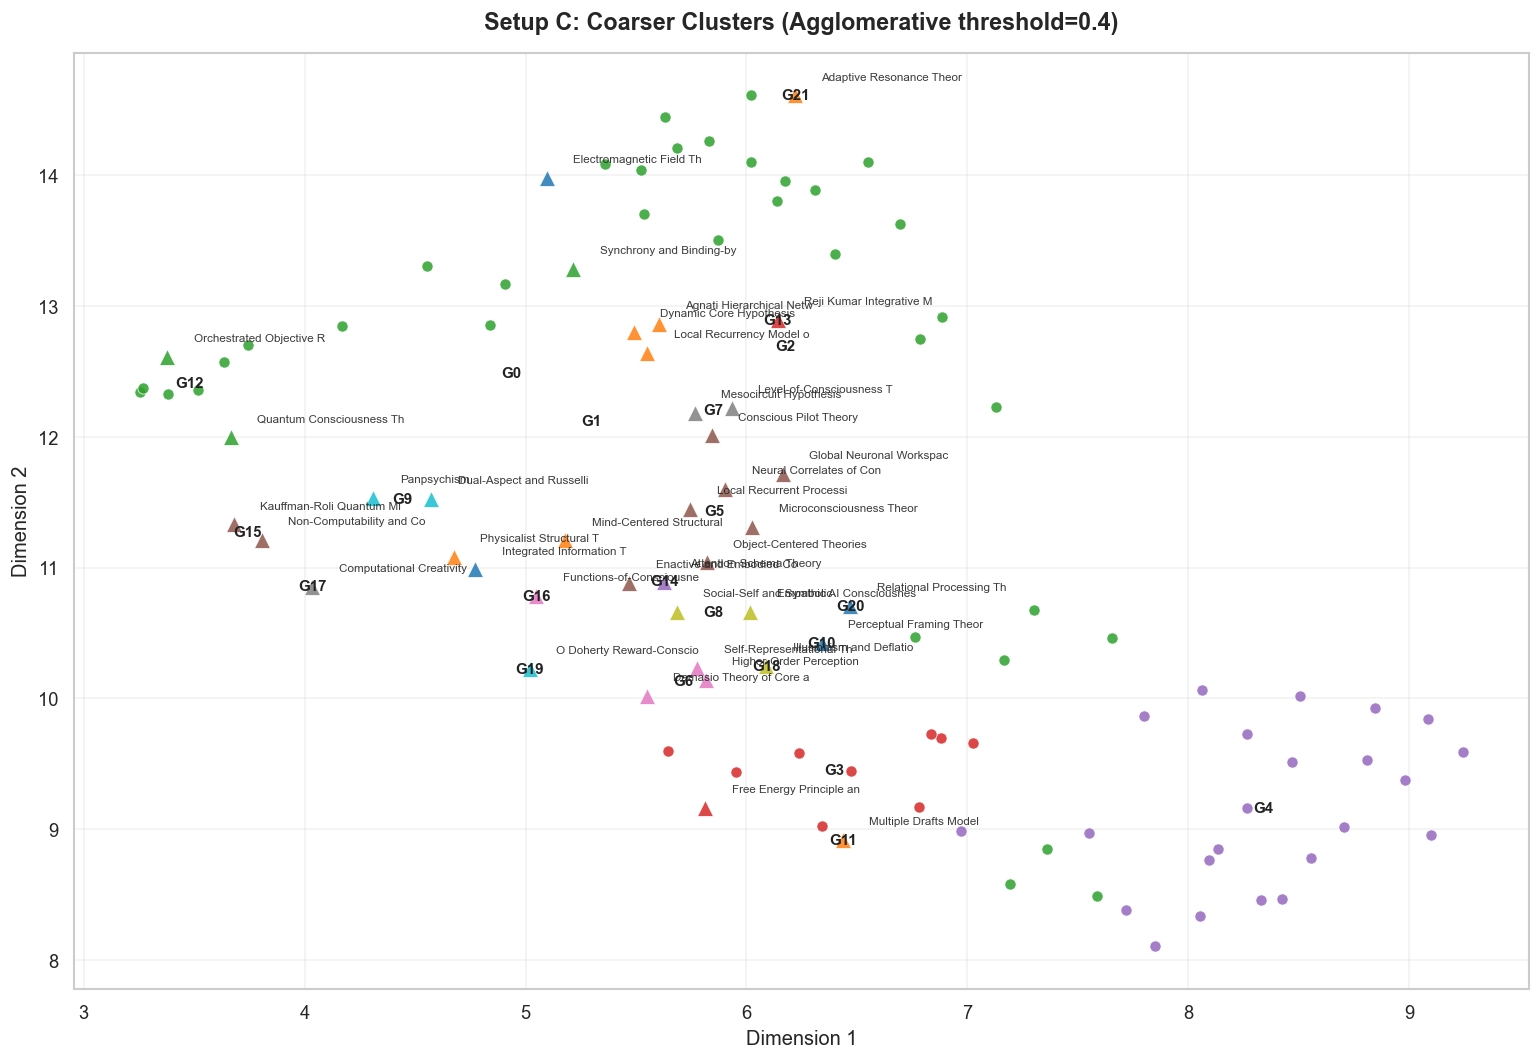

Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_cluster_map_setupC_coarse_clusters.png
Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_cluster_map_setupC_coarse_summary.csv
Coarse cluster count: 22


group,coarse_cluster_id,n_ai,n_known,n_total
0,2,29,1,30
1,4,23,0,23
2,3,9,1,10
3,12,6,2,8
4,5,0,7,7
5,1,0,5,5
6,6,0,3,3
7,0,0,2,2
8,7,0,2,2
9,8,0,2,2


In [10]:
# Setup C: coarser clustering with larger distance threshold.
COARSE_DISTANCE_THRESHOLD = 0.40

try:
    coarse_clusterer = AgglomerativeClustering(
        n_clusters=None,
        metric='cosine',
        linkage='average',
        distance_threshold=COARSE_DISTANCE_THRESHOLD,
    )
except TypeError:
    coarse_clusterer = AgglomerativeClustering(
        n_clusters=None,
        affinity='cosine',
        linkage='average',
        distance_threshold=COARSE_DISTANCE_THRESHOLD,
    )

coarse_labels = coarse_clusterer.fit_predict(all_embeddings)
setup_c_df = cluster_map_df.copy()
setup_c_df['coarse_cluster_id'] = coarse_labels.astype(int)

fig, ax = plt.subplots(figsize=(13, 9))
coarse_ids = sorted(setup_c_df['coarse_cluster_id'].unique().tolist())
coarse_palette = sns.color_palette('tab10', n_colors=max(1, len(coarse_ids)))
coarse_color = {cid: coarse_palette[i % len(coarse_palette)] for i, cid in enumerate(coarse_ids)}

for grp, marker, size in [('AI', 'o', 45), ('Known', '^', 90)]:
    gdf = setup_c_df[setup_c_df['group'] == grp]
    for cid in coarse_ids:
        sub = gdf[gdf['coarse_cluster_id'] == cid]
        if sub.empty:
            continue
        ax.scatter(
            sub['x'], sub['y'],
            c=[coarse_color[cid]],
            marker=marker,
            s=size,
            alpha=0.85,
            edgecolors='white',
            linewidths=0.5,
        )

# Cluster centroid labels (coarse).
for cid in coarse_ids:
    cdf = setup_c_df[setup_c_df['coarse_cluster_id'] == cid]
    cx = float(cdf['x'].mean())
    cy = float(cdf['y'].mean())
    ax.text(cx, cy, f'G{cid}', fontsize=9, fontweight='bold', color='#222222', ha='center', va='center')

known_pts = setup_c_df[setup_c_df['group'] == 'Known']
for _, row in known_pts.iterrows():
    ax.text(row['x'] + 0.12, row['y'] + 0.12, str(row['theory_name'])[:24], fontsize=7, alpha=0.9)

ax.set_title(
    f'Setup C: Coarser Clusters (Agglomerative threshold={COARSE_DISTANCE_THRESHOLD})',
    fontsize=14, fontweight='bold', pad=14
    )
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(output_dir / 'theory_cluster_map_setupC_coarse_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

coarse_summary = (
    setup_c_df.groupby(['coarse_cluster_id', 'group']).size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={'AI': 'n_ai', 'Known': 'n_known'})
    .sort_values(['n_ai', 'n_known'], ascending=False)
    .reset_index(drop=True)
    )
coarse_summary['n_total'] = coarse_summary['n_ai'] + coarse_summary['n_known']
coarse_summary.to_csv(output_dir / 'theory_cluster_map_setupC_coarse_summary.csv', index=False)

print(f"Saved: {output_dir / 'theory_cluster_map_setupC_coarse_clusters.png'}")
print(f"Saved: {output_dir / 'theory_cluster_map_setupC_coarse_summary.csv'}")
print(f"Coarse cluster count: {setup_c_df['coarse_cluster_id'].nunique()}")
coarse_summary.head(20)

### 5.1.4 Setup D: Hierarchical Dendrogram

Hierarchical clustering dendrogram over joint AI + known embeddings using cosine distance (average linkage).

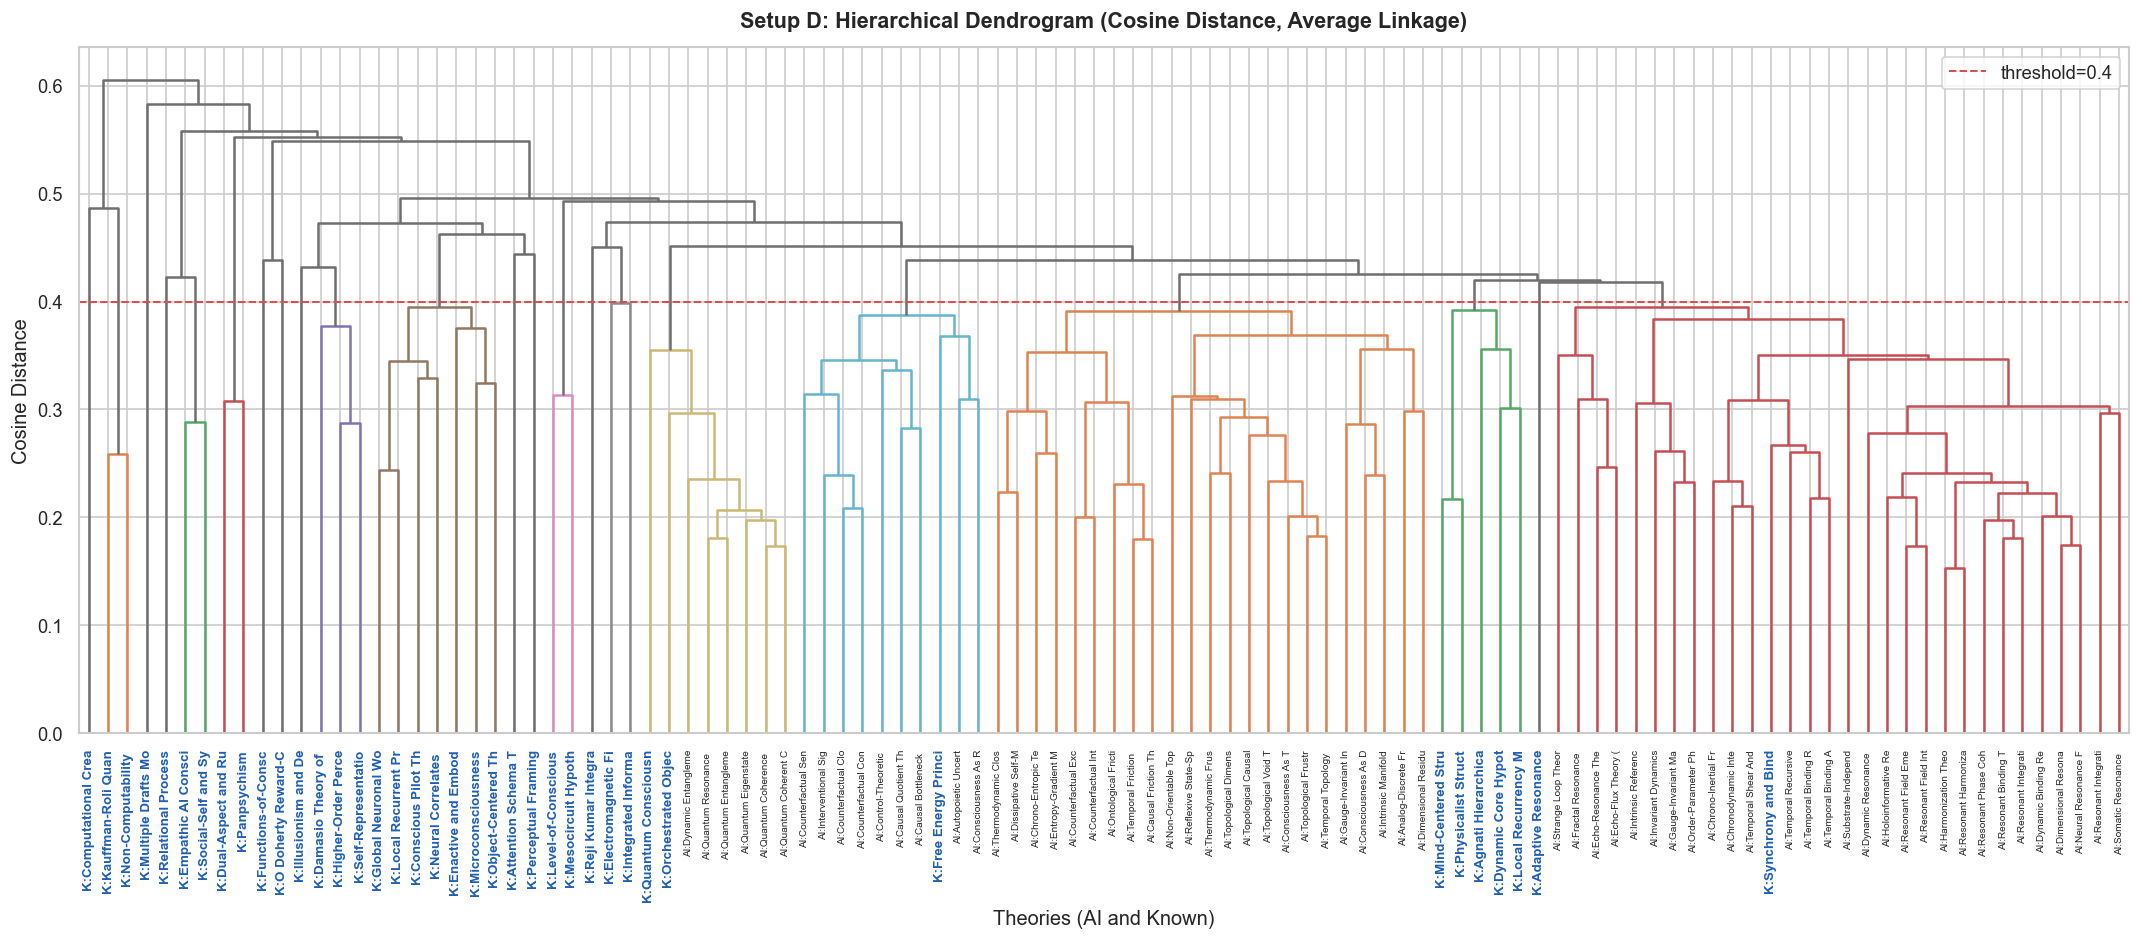

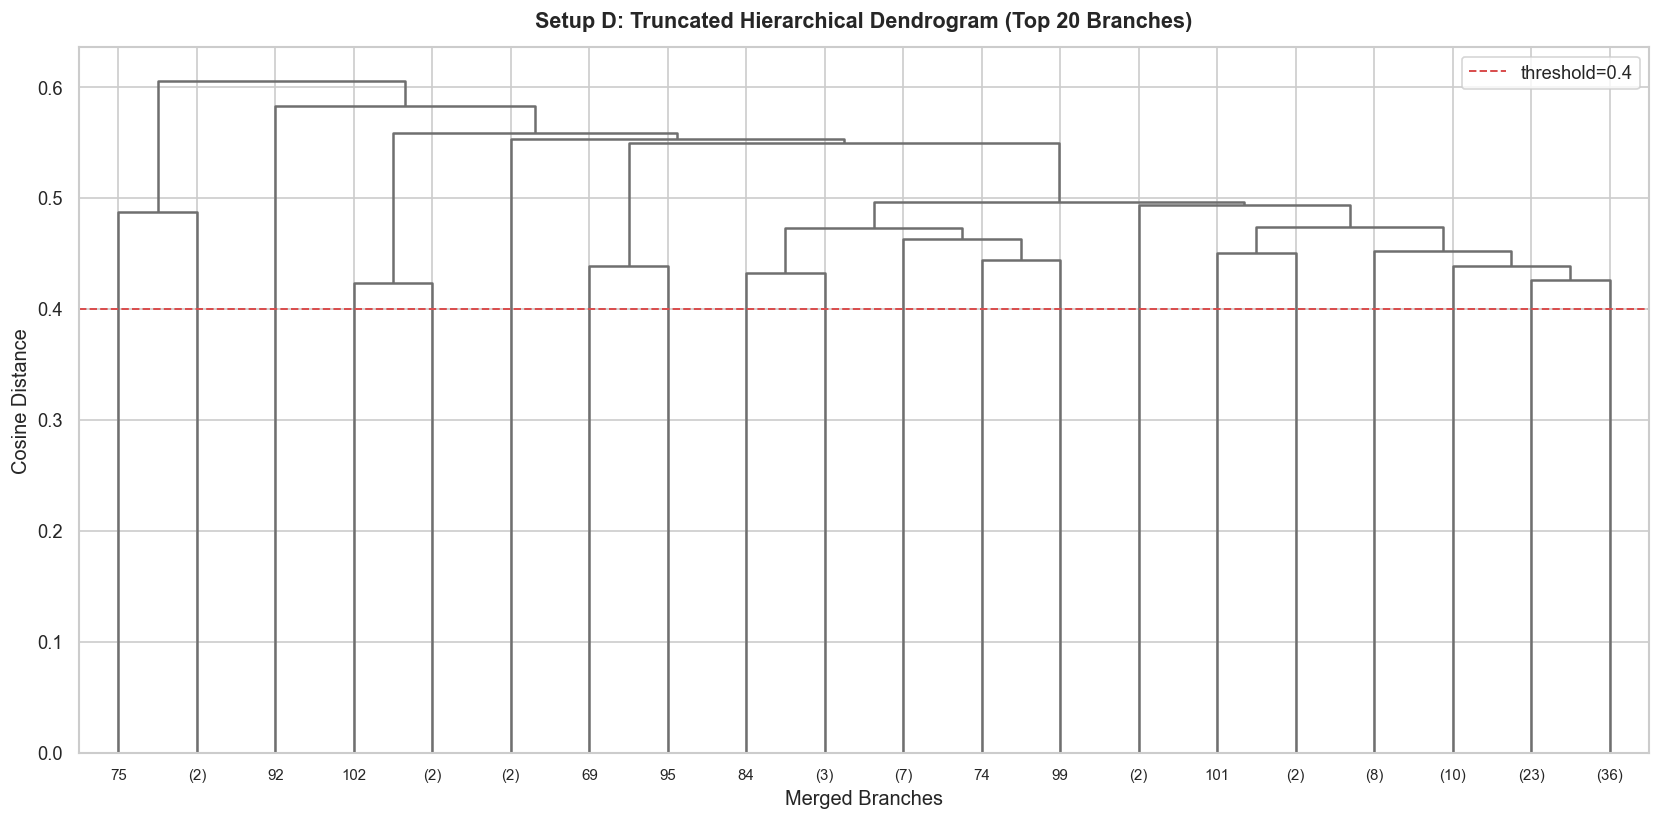

Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_dendrogram_full.png
Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_dendrogram_truncated.png
Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_dendrogram_membership.csv
Saved: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/results/test3_theory_generation_alternative/theory_dendrogram_cluster_summary.csv
Dendrogram clusters at threshold 0.4: 22


group,dendro_cluster_id,n_ai,n_known,n_total
0,20,29,1,30
1,18,23,0,23
2,17,9,1,10
3,16,6,2,8
4,10,0,7,7
5,19,0,5,5
6,8,0,3,3
7,1,0,2,2
8,3,0,2,2
9,5,0,2,2


In [11]:
# Setup D: hierarchical dendrogram (cosine distance, average linkage).
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

DENDROGRAM_DISTANCE_THRESHOLD = 0.40

# Build compact labels with source prefix.
dendro_labels = [
    (f"AI:{name[:18]}") if grp == 'AI' else (f"K:{name[:18]}")
    for name, grp in zip(all_names, all_group)
]

# Pairwise cosine distances and hierarchical linkage.
dendro_dist = pdist(all_embeddings, metric='cosine')
dendro_linkage = linkage(dendro_dist, method='average')

# Full dendrogram (readable but dense).
fig, ax = plt.subplots(figsize=(18, 8))
dendrogram(
    dendro_linkage,
    labels=dendro_labels,
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=DENDROGRAM_DISTANCE_THRESHOLD,
    above_threshold_color='#6f6f6f',
    ax=ax,
    )

# Emphasize known-theory leaf labels on x-axis.
for tick in ax.get_xmajorticklabels():
    if tick.get_text().startswith('K:'):
        tick.set_fontweight('bold')
        tick.set_color('#1f5fb3')
        tick.set_fontsize(8)
    else:
        tick.set_fontsize(6)

ax.axhline(
    y=DENDROGRAM_DISTANCE_THRESHOLD,
    color='#d94f4f',
    linestyle='--',
    linewidth=1.2,
    label=f'threshold={DENDROGRAM_DISTANCE_THRESHOLD}'
    )
ax.set_title('Setup D: Hierarchical Dendrogram (Cosine Distance, Average Linkage)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Theories (AI and Known)')
ax.set_ylabel('Cosine Distance')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig(output_dir / 'theory_dendrogram_full.png', dpi=300, bbox_inches='tight')
plt.show()

# Truncated dendrogram for publication readability.
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(
    dendro_linkage,
    truncate_mode='lastp',
    p=20,
    show_leaf_counts=True,
    leaf_rotation=0,
    leaf_font_size=9,
    color_threshold=DENDROGRAM_DISTANCE_THRESHOLD,
    above_threshold_color='#6f6f6f',
    ax=ax,
    )
ax.axhline(
    y=DENDROGRAM_DISTANCE_THRESHOLD,
    color='#d94f4f',
    linestyle='--',
    linewidth=1.2,
    label=f'threshold={DENDROGRAM_DISTANCE_THRESHOLD}'
    )
ax.set_title('Setup D: Truncated Hierarchical Dendrogram (Top 20 Branches)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Merged Branches')
ax.set_ylabel('Cosine Distance')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig(output_dir / 'theory_dendrogram_truncated.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster membership at the dendrogram threshold.
dendro_cluster_ids = fcluster(dendro_linkage, t=DENDROGRAM_DISTANCE_THRESHOLD, criterion='distance')
dendro_df = pd.DataFrame({
    'theory_name': all_names,
    'group': all_group,
    'dendro_cluster_id': dendro_cluster_ids.astype(int),
})
dendro_summary = (
    dendro_df.groupby(['dendro_cluster_id', 'group']).size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={'AI': 'n_ai', 'Known': 'n_known'})
    .sort_values(['n_ai', 'n_known'], ascending=False)
    .reset_index(drop=True)
    )
dendro_summary['n_total'] = dendro_summary['n_ai'] + dendro_summary['n_known']

dendro_df.to_csv(output_dir / 'theory_dendrogram_membership.csv', index=False)
dendro_summary.to_csv(output_dir / 'theory_dendrogram_cluster_summary.csv', index=False)

print(f"Saved: {output_dir / 'theory_dendrogram_full.png'}")
print(f"Saved: {output_dir / 'theory_dendrogram_truncated.png'}")
print(f"Saved: {output_dir / 'theory_dendrogram_membership.csv'}")
print(f"Saved: {output_dir / 'theory_dendrogram_cluster_summary.csv'}")
print(f"Dendrogram clusters at threshold {DENDROGRAM_DISTANCE_THRESHOLD}: {dendro_df['dendro_cluster_id'].nunique()}")
dendro_summary.head(20)

In [12]:
# Diagnostic: inspect the left-side island in the 2D map.

# Preserve row index so we can map back to AI metadata by position.
diag_df = cluster_map_df.reset_index(drop=False).rename(columns={'index': 'point_idx'})

# Heuristic region for the visible left-middle island.
left_island = diag_df[(diag_df['x'] < 7.0) & (diag_df['y'] > 0.7) & (diag_df['y'] < 1.9)].copy()

print('Left-island candidate points:', len(left_island))
print('Group counts:')
print(left_island['group'].value_counts(dropna=False))
print('\nCluster id counts:')
print(left_island['cluster_id'].value_counts(dropna=False).sort_index())

# AI points are first in all_names/all_group by construction.
n_ai = len(ai_unique_df)
left_ai = left_island[left_island['group'] == 'AI'].copy()
text_col = 'full_text' if 'full_text' in ai_unique_df.columns else 'representative_text'

if len(left_ai):
    # Position-aligned metadata from ai_unique_df.
    left_ai['ai_idx'] = left_ai['point_idx'].astype(int)
    left_ai = left_ai[left_ai['ai_idx'] < n_ai].copy()

    left_ai['model'] = ai_unique_df.iloc[left_ai['ai_idx']]['model'].to_numpy()
    left_ai['char_words'] = (
        ai_unique_df.iloc[left_ai['ai_idx']][text_col]
        .astype(str)
        .str.split()
        .str.len()
        .to_numpy()
    )

    # Attach nearest known similarity and nearest known name.
    known_names = known_unique_df['canonical_name'].astype(str).tolist()
    nearest_sim = []
    nearest_known = []
    for i in left_ai['ai_idx'].astype(int).tolist():
        row = similarity_matrix_combined[i]
        j = int(np.argmax(row))
        nearest_sim.append(float(row[j]))
        nearest_known.append(known_names[j])

    left_ai['nearest_known_similarity'] = nearest_sim
    left_ai['nearest_known_theory'] = nearest_known

    print('\nAI model counts in left island:')
    print(left_ai['model'].value_counts(dropna=False))

    print(f"\nWord-count stats (left island AI {text_col}):")
    print(left_ai['char_words'].describe().to_string())

    print('\nNearest-known similarity stats (left island AI):')
    print(left_ai['nearest_known_similarity'].describe().to_string())

    display_cols = [
        'theory_name', 'model', 'cluster_id', 'x', 'y',
        'nearest_known_similarity', 'nearest_known_theory', 'char_words'
    ]
    print('\nLeft-island AI members:')
    display(left_ai[display_cols].sort_values(['model', 'theory_name']).reset_index(drop=True))

# Compare against full AI population for sanity.
all_words = ai_unique_df[text_col].astype(str).str.split().str.len()
print(f"\nGlobal AI {text_col} word-count stats:")
print(all_words.describe().to_string())

Left-island candidate points: 0
Group counts:
Series([], Name: count, dtype: int64)

Cluster id counts:
Series([], Name: count, dtype: int64)

Global AI representative_text word-count stats:
count     67.000000
mean     116.074627
std        5.105889
min      103.000000
25%      113.500000
50%      117.000000
75%      120.000000
max      126.000000


In [13]:
# Diagnostic: model-level embedding compactness and near-duplicate checks.
from sklearn.metrics.pairwise import cosine_similarity

emb = np.asarray(ai_unique_emb)
models = ai_unique_df['model'].astype(str).to_numpy()
text_col = 'full_text' if 'full_text' in ai_unique_df.columns else 'representative_text'
texts = ai_unique_df[text_col].astype(str).to_numpy()

rows = []
for m in sorted(pd.unique(models)):
    idx = np.where(models == m)[0]
    E = emb[idx]
    S = cosine_similarity(E, E)
    mask = ~np.eye(len(idx), dtype=bool)
    off = S[mask]

    # Near-duplicate proxy: very high cosine similarity among same-model theories.
    dup_095 = float((off >= 0.95).mean()) if len(off) else np.nan
    dup_090 = float((off >= 0.90).mean()) if len(off) else np.nan

    rows.append({
        'model': m,
        'n': len(idx),
        'within_model_mean_cosine': float(off.mean()),
        'within_model_median_cosine': float(np.median(off)),
        'within_model_q95_cosine': float(np.quantile(off, 0.95)),
        'near_dup_rate_ge_0p90': dup_090,
        'near_dup_rate_ge_0p95': dup_095,
    })

compact_df = pd.DataFrame(rows).sort_values('within_model_mean_cosine', ascending=False)
print('Within-model compactness (higher => tighter model-specific cluster tendency):')
display(compact_df)

# Llama-only lexical fingerprint check.
ll_idx = np.where(models == 'llama-3.3-70b-instruct')[0]
if len(ll_idx):
    ll_names = ai_unique_df.iloc[ll_idx]['canonical_name'].astype(str)
    print('Llama frequent name tokens (top 20):')
    tokens = (
        ll_names.str.lower()
        .str.replace(r'[^a-z0-9\s-]', ' ', regex=True)
        .str.split()
        .explode()
    )
    token_counts = tokens.value_counts().head(20)
    display(token_counts.to_frame('count'))

Within-model compactness (higher => tighter model-specific cluster tendency):


,model,n,within_model_mean_cosine,within_model_median_cosine,within_model_q95_cosine,near_dup_rate_ge_0p90,near_dup_rate_ge_0p95
0,claude-3.7-sonnet,9,0.687493,0.675991,0.821227,0.0,0.0
4,llama-3.3-70b-instruct,5,0.680932,0.658287,0.846773,0.0,0.0
2,gemini-3.1-pro-preview,18,0.663710,0.657053,0.776456,0.0,0.0
5,perplexity-sonar-pro,6,0.627819,0.623902,0.728604,0.0,0.0
1,deepseek-v3.2,13,0.619207,0.612306,0.790655,0.0,0.0
3,gpt-5.2,16,0.613142,0.609834,0.732055,0.0,0.0


Llama frequent name tokens (top 20):


,count
canonical_name,
theory,5
harmonization,2
echo-resonance,1
ert,1
echo-flux,1
eft,1
fractal,1
resonance,1
frt,1


In [14]:
# Diagnostic: repeated semantic canonical names by representative model.
name_counts = (
    ai_unique_df.assign(
        theory_name_norm=ai_unique_df['canonical_name'].astype(str).str.strip().str.lower(),
        model_norm=ai_unique_df['model'].astype(str).str.strip().str.lower(),
    )
    .groupby(['model_norm', 'theory_name_norm'])
    .size()
    .reset_index(name='count')
    .sort_values(['model_norm', 'count'], ascending=[True, False])
)

print('Top repeated canonical names per model (count > 1):')
repeats = name_counts[name_counts['count'] > 1]
if len(repeats):
    display(repeats.groupby('model_norm').head(10))
else:
    print('No repeated canonical names within representative models.')

print('\nUnique-name ratio per model (semantic space):')
uniq_ratio = (
    ai_unique_df.assign(model_norm=ai_unique_df['model'].astype(str).str.strip().str.lower())
    .groupby('model_norm')['canonical_name']
    .agg(n_total='size', n_unique='nunique')
)
uniq_ratio['unique_ratio'] = uniq_ratio['n_unique'] / uniq_ratio['n_total']
display(uniq_ratio.sort_values('unique_ratio'))

Top repeated canonical names per model (count > 1):
No repeated canonical names within representative models.

Unique-name ratio per model (semantic space):


,n_total,n_unique,unique_ratio
model_norm,,,
claude-3.7-sonnet,9,9,1.0
deepseek-v3.2,13,13,1.0
gemini-3.1-pro-preview,18,18,1.0
gpt-5.2,16,16,1.0
llama-3.3-70b-instruct,5,5,1.0
perplexity-sonar-pro,6,6,1.0
